In [1]:
# Import necessary packages
import warnings
import pandas as pd
import numpy as np
import string
import re
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP-related imports
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Scikit-learn imports for model evaluation and preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_curve, auc, confusion_matrix)

# PyTorch imports for building and training neural networks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Data processing imports from torchtext (if needed)
from transformers import AutoTokenizer # For loading a pre-trained tokenizer

# Suppress specific warnings
warnings.filterwarnings("ignore", message=r".*datetime\.datetime\.utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
df_sent = pd.read_csv('sentiment_prep.csv')

In [ ]:
df_sent = df_sent.dropna(subset=["review_text"])

In [ ]:
train, test = train_test_split(
    df_sent,
    test_size=0.2,    # 20% of data for testing
    random_state=42,  # for reproducible splits
    shuffle=True      # ensures random distribution
)

In [ ]:
train.head()

In [ ]:
test.head()

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

def remove_numbers(text):
    return re.sub(r'\d+', '', text) 

def remove_nonsensical(text):
    return text.replace('\n', ' ').replace('\r', ' ')

#Dictionary for converting emoticons
EMOTICONS = {
    r":‑\)": "Happy face or smiley",
    r":\)": "Happy face or smiley",
    r":-\]": "Happy face or smiley",
    r":\]": "Happy face or smiley",
    r":-3": "Happy face smiley",
    r":3": "Happy face smiley",
    r":->": "Happy face smiley",
    r":>": "Happy face smiley",
    r"8-\)": "Happy face smiley",
    r":o\)": "Happy face smiley",
    r":-\}": "Happy face smiley",
    r":\}": "Happy face smiley",
    r":-\)": "Happy face smiley",
    r":c\)": "Happy face smiley",
    r":\^\)": "Happy face smiley",
    r"=\]": "Happy face smiley",
    r"=\)": "Happy face smiley",
    r":‑D": "Laughing, big grin or laugh with glasses",
    r":D": "Laughing, big grin or laugh with glasses",
    r"8‑D": "Laughing, big grin or laugh with glasses",
    r"8D": "Laughing, big grin or laugh with glasses",
    r"X‑D": "Laughing, big grin or laugh with glasses",
    r"XD": "Laughing, big grin or laugh with glasses",
    r"=D": "Laughing, big grin or laugh with glasses",
    r"=3": "Laughing, big grin or laugh with glasses",
    r"B\^D": "Laughing, big grin or laugh with glasses",
    r":-\)\)": "Very happy",
    r":‑\(": "Frown, sad, andry or pouting",
    r":-\(": "Frown, sad, andry or pouting",
    r":\(": "Frown, sad, andry or pouting",
    r":‑c": "Frown, sad, andry or pouting",
    r":c": "Frown, sad, andry or pouting",
    r":‑<": "Frown, sad, andry or pouting",
    r":<": "Frown, sad, andry or pouting",
    r":‑\[": "Frown, sad, andry or pouting",
    r":\[": "Frown, sad, andry or pouting",
    r":-\|\|": "Frown, sad, andry or pouting",
    r">:\[": "Frown, sad, andry or pouting",
    r":\{": "Frown, sad, andry or pouting",
    r":@": "Frown, sad, andry or pouting",
    r">:\(": "Frown, sad, andry or pouting",
    r":'‑\(": "Crying",
    r":'\(": "Crying",
    r":'‑\)": "Tears of happiness",
    r":'\)": "Tears of happiness",
    r"D‑':": "Horror",
    r"D:<": "Disgust",
    r"D:": "Sadness",
    r"D8": "Great dismay",
    r"D;": "Great dismay",
    r"D=": "Great dismay",
    r"DX": "Great dismay",
    r":‑O": "Surprise",
    r":O": "Surprise",
    r":‑o": "Surprise",
    r":o": "Surprise",
    r":-0": "Shock",
    r"8‑0": "Yawn",
    r">:O": "Yawn",
    r":-\*": "Kiss",
    r":\*": "Kiss",
    r":X": "Kiss",
    r";‑\)": "Wink or smirk",
    r";\)": "Wink or smirk",
    r"\*-\)": "Wink or smirk",
    r"\*\)": "Wink or smirk",
    r";‑\]": "Wink or smirk",
    r";\]": "Wink or smirk",
    r";\^\)": "Wink or smirk",
    r":‑,": "Wink or smirk",
    r";D": "Wink or smirk",
    r":‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"X‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"XP": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"d:": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"=p": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r">:P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":-[.]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":S": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":‑\|": "Straight face",
    r":\|": "Straight face",
    r":$": "Embarrassed or blushing",
    r":‑x": "Sealed lips or wearing braces or tongue-tied",
    r":x": "Sealed lips or wearing braces or tongue-tied",
    r":‑#": "Sealed lips or wearing braces or tongue-tied",
    r":#": "Sealed lips or wearing braces or tongue-tied",
    r":‑&": "Sealed lips or wearing braces or tongue-tied",
    r":&": "Sealed lips or wearing braces or tongue-tied",
    r"O:‑\)": "Angel, saint or innocent",
    r"O:\)": "Angel, saint or innocent",
    r"0:‑3": "Angel, saint or innocent",
    r"0:3": "Angel, saint or innocent",
    r"0:‑\)": "Angel, saint or innocent",
    r"0:\)": "Angel, saint or innocent",
    r":‑b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"0;\^\)": "Angel, saint or innocent",
    r">:‑\)": "Evil or devilish",
    r">:\)": "Evil or devilish",
    r"\}:‑\)": "Evil or devilish",
    r"\}:\)": "Evil or devilish",
    r"3:‑\)": "Evil or devilish",
    r"3:\)": "Evil or devilish",
    r">;\)": "Evil or devilish",
    r"\|;‑\)": "Cool",
    r"\|‑O": "Bored",
    r":‑J": "Tongue-in-cheek",
    r"#‑\)": "Party all night",
    r"%‑\)": "Drunk or confused",
    r"%\)": "Drunk or confused",
    r":-###..": "Being sick",
    r":###..": "Being sick",
    r"<:‑\|": "Dump",
    r"\(>_<\)": "Troubled",
    r"\(>_<\)>": "Troubled",
    r"\(';'\)": "Baby",
    r"\(\^\^>``": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(\^_\^;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(~_~;\) \(・\.・;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-\)zzz": "Sleeping",
    r"\(\^_-\)": "Wink",
    r"\(\(\+_\+\)\)": "Confused",
    r"\(\+o\+\)": "Confused",
    r"\(o\|o\)": "Ultraman",
    r"\^_\^": "Joyful",
    r"\(\^_\^\)/": "Joyful",
    r"\(\^O\^\)／": "Joyful",
    r"\(\^o\^\)／": "Joyful",
    r"\(__\)": "Kowtow as a sign of respect, or dogeza for apology",
    r"_\(\._\.\)_": "Kowtow as a sign of respect, or dogeza for apology",
    r"<\(_ _\)>": "Kowtow as a sign of respect, or dogeza for apology",
    r"<m\(__\)m>": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(__\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(_ _\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"\('_'\)": "Sad or Crying",
    r"\(/_;\)": "Sad or Crying",
    r"\(T_T\) \(;_;\)": "Sad or Crying",
    r"\(;_;": "Sad of Crying",
    r"\(;_:\)": "Sad or Crying",
    r"\(;O;\)": "Sad or Crying",
    r"\(:_;\)": "Sad or Crying",
    r"\(ToT\)": "Sad or Crying",
    r";_;": "Sad or Crying",
    r";-;": "Sad or Crying",
    r";n;": "Sad or Crying",
    r";;": "Sad or Crying",
    r"Q\.Q": "Sad or Crying",
    r"T\.T": "Sad or Crying",
    r"QQ": "Sad or Crying",
    r"Q_Q": "Sad or Crying",
    r"\(-\.-\)": "Shame",
    r"\(-_-\)": "Shame",
    r"\(一一\)": "Shame",
    r"\(；一_一\)": "Shame",
    r"\(=_=\)": "Tired",
    r"\(=\^\·\^=\)": "cat",
    r"\(=\^\·\·\^=\)": "cat",
    r"=_\^=": "cat",
    r"\(\.\.\)": "Looking down",
    r"\(\._\.\)": "Looking down",
    r"\^m\^": "Giggling with hand covering mouth",
    r"\(\・\・?": "Confusion",
    r"\(?_?\)": "Confusion",
    r">\^_\^<": "Normal Laugh",
    r"<\^!\^>": "Normal Laugh",
    r"\^/\^": "Normal Laugh",
    r"\（\*\^_\^\*）": "Normal Laugh",
    r"\(\^<\^\) \(\^\.\^\)": "Normal Laugh",
    r"\(^\^\)": "Normal Laugh",
    r"\(\^\.\^\)": "Normal Laugh",
    r"\(\^_\^\.\)": "Normal Laugh",
    r"\(\^_\^\)": "Normal Laugh",
    r"\(\^\^\)": "Normal Laugh",
    r"\(\^J\^\)": "Normal Laugh",
    r"\(\*\^\.\^\*\)": "Normal Laugh",
    r"\(\^—\^\）": "Normal Laugh",
    r"\(#\^\.\^#\)": "Normal Laugh",
    r"\（\^—\^\）": "Waving",
    r"\(;_;\)/~~~": "Waving",
    r"\(\^\.\^\)/~~~": "Waving",
    r"\(-_-\)/~~~ \($\·\·\)/~~~": "Waving",
    r"\(T_T\)/~~~": "Waving",
    r"\(ToT\)/~~~": "Waving",
    r"\(\*\^0\^\*\)": "Excited",
    r"\(\*_\*\)": "Amazed",
    r"\(\*_\*;": "Amazed",
    r"\(\+_\+\) \(@_@\)": "Amazed",
    r"\(\*\^\^\)v": "Laughing,Cheerful",
    r"\(\^_\^\)v": "Laughing,Cheerful",
    r"\(\(d[-_-]b\)\)": "Headphones,Listening to music",
    r'\(-"-\)': "Worried",
    r"\(ーー;\)": "Worried",
    r"\(\^0_0\^\)": "Eyeglasses",
    r"\(\＾ｖ\＾\)": "Happy",
    r"\(\＾ｕ\＾\)": "Happy",
    r"\(\^\)o\(\^\)": "Happy",
    r"\(\^O\^\)": "Happy",
    r"\(\^o\^\)": "Happy",
    r"\)\^o\^\(": "Happy",
    r":O o_O": "Surprised",
    r"o_0": "Surprised",
    r"o\.O": "Surprised",
    r"\(o\.o\)": "Surprised",
    r"oO": "Surprised",
    r"\(\*￣m￣\)": "Dissatisfied",
    r"\(‘A`\)": "Snubbed or Deflated"}

In [ ]:
def convert_emoticons(text):
    for emot in EMOTICONS:
        text = re.sub(u'('+emot+')', "_".join(EMOTICONS[emot].replace(",","").split()), text)
    return text

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])


def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

In [ ]:
# Convert the training set
train["review_text"] = train["review_text"].str.lower()
train["review_text"] = train["review_text"].apply(lambda text: remove_urls(text))
PUNCT_TO_REMOVE = string.punctuation
train["review_text"] = train["review_text"].apply(lambda text: remove_punctuation(text))
train["review_text"] = train["review_text"].apply(lambda text: remove_numbers(text))
train["review_text"] = train["review_text"].apply(lambda text: remove_nonsensical(text))
train["review_text"] = train["review_text"].apply(lambda text: convert_emoticons(text))
STOPWORDS = set(stopwords.words('english'))
train["review_text"] = train["review_text"].apply(lambda text: remove_stopwords(text))
cnt = Counter()
for text in train["review_text"].values:
    for word in text.split():
        cnt[word] += 1     
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
train["review_text"] = train["review_text"].apply(lambda text: remove_freqwords(text))
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])
train["review_text"] = train["review_text"].apply(lambda text: remove_rarewords(text))
stemmer = PorterStemmer()
train["review_text"] = train["review_text"].apply(lambda text: stem_words(text))
lemmatizer = WordNetLemmatizer()
train["review_text"] = train["review_text"].apply(lambda text: lemmatize_words(text))
train.head()

In [ ]:
#save the converted training set
train_clean = train.copy()
train_clean.to_pickle('train_clean.pkl')

In [ ]:
# Convert the test set
test["review_text"] = test["review_text"].str.lower()
test["review_text"] = test["review_text"].apply(lambda text: remove_urls(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_punctuation(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_numbers(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_nonsensical(text))
test["review_text"] = test["review_text"].apply(lambda text: convert_emoticons(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_stopwords(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_freqwords(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_rarewords(text))

test["review_text"] = test["review_text"].apply(lambda text: stem_words(text))
test["review_text"] = test["review_text"].apply(lambda text: lemmatize_words(text))

test.head()

In [ ]:
test_clean = test.copy()
test_clean.to_pickle('test_clean.pkl')

In [2]:
train_clean= pd.read_pickle('train_clean.pkl')
test_clean= pd.read_pickle('test_clean.pkl')

In [ ]:
print(train_clean.head())

In [ ]:
print(test_clean.head())

In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from tqdm import tqdm

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name, use_safetensors=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


def batch_translate(texts, batch_size=16):
    translated_texts = []
    
    try:
        tgt_lang_id = tokenizer.convert_tokens_to_ids("eng_Latn")
    except:
        tgt_lang_id = tokenizer.lang_code_to_id["eng_Latn"]

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i : i + batch_size].fillna("").astype(str).tolist()
        
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=128
            )
        
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated_texts.extend(decoded)
        
    return translated_texts

test_subset = train_clean['review_text'].head(100)
train_clean.loc[test_subset.index, 'english_review_text'] = batch_translate(test_subset)

print(train_clean[['review_text', 'english_review_text']].head())


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Translating: 100%|██████████| 7/7 [00:38<00:00,  5.44s/it]

                                             review_text  \
26251                                    veio pwla metad   
30065                                              otimo   
5556    luminária linda boa qualidad chegou bem embalada   
27869  quero saber porqu tanto atraso na minha encome...   
5737   ótima compra qualidad excelent valor melhor ai...   

                                     english_review_text  
26251                The metadata came from the process.  
30065                                    It's very good.  
5556   The beautiful good quality of the light came w...  
27869  I want to know why my order is so late because...  
5737   Optimum purchase quality excelent value better...  


In [6]:
train_clean.head()

,order_id,review_score,review_text,customer_unique_id,review_id,category_english,macro_category,english_review_text
26251,f585ab48a4d0027744dd2912cb42a2cb,1,veio pwla metad,919b613e7aa171cb4ca017c049fbc5da,2f210df09863168e9f9372e43ce53528,garden_tools,Home & Living,The metadata came from the process.
30065,01a1553cddb473cec004af5ce2192f1c,4,otimo,704c21a02e59001049f14ec33b3b0be0,bb4adccbf5dec1dc01a9fadb2fe3a6bf,home_construction,Home & Living,It's very good.
5556,57274b4596c5c76c54168e88dbcf922f,5,luminária linda boa qualidad chegou bem embalada,a7175616bbd961493941fa1159d2033f,61364556967b7fbdbda6a7a71573ce70,garden_tools,Home & Living,The beautiful good quality of the light came w...
27869,027a84a16c22c706669f35d578853f3e,1,quero saber porqu tanto atraso na minha encome...,5250c9708a2b44c10bd5cd9f94235290,bc99e8911baf06b4d1d126d9f23baeb3,bed_bath_table,Home & Living,I want to know why my order is so late because...
5737,5c2bbf0c34b51eec1e79c0d7ef81f86b,5,ótima compra qualidad excelent valor melhor ai...,7295177fabcd2c6e9a4a3bd094a91f50,3301fa1df8a3f4c70ea61d5dd8c7c860,garden_tools,Home & Living,Optimum purchase quality excelent value better...


In [8]:
# 1. Translate the Training Set (approx. 31,000+ records)
print(f"Starting translation for the Training Set: {len(train_clean)} records...")
# Using batch_size=32 for better performance; reduce to 16 if memory issues occur
train_clean['english_review_text'] = batch_translate(train_clean['review_text'], batch_size=32)

# Save Training Set to CSV immediately
train_clean.to_csv("train_translated_final.csv", index=False)
print("✅ Training Set translation complete! Saved as 'train_translated_final.csv'")

# 2. Translate the Test Set (approx. 5,000+ records)
print(f"\nStarting translation for the Test Set: {len(test_clean)} records...")
test_clean['english_review_text'] = batch_translate(test_clean['review_text'], batch_size=32)

# Save Test Set to CSV immediately
test_clean.to_csv("test_translated_final.csv", index=False)
print("✅ Test Set translation complete! Saved as 'test_translated_final.csv'")

# Final Preview
print("\n--- Final Results Preview ---")
print("Train Set (Head):\n", train_clean[['review_text', 'english_review_text']].head())
print("\nTest Set (Head):\n", test_clean[['review_text', 'english_review_text']].head())

Starting translation for the Training Set: 31312 records...


Translating: 100%|██████████| 979/979 [2:29:41<00:00,  9.17s/it]


✅ Training Set translation complete! Saved as 'train_translated_final.csv'

Starting translation for the Test Set: 7828 records...


Translating: 100%|██████████| 245/245 [34:33<00:00,  8.46s/it]


✅ Test Set translation complete! Saved as 'test_translated_final.csv'

--- Final Results Preview ---
Train Set (Head):
                                              review_text  \
26251                                    veio pwla metad   
30065                                              otimo   
5556    luminária linda boa qualidad chegou bem embalada   
27869  quero saber porqu tanto atraso na minha encome...   
5737   ótima compra qualidad excelent valor melhor ai...   

                                     english_review_text  
26251                The metadata came from the process.  
30065                                    It's very good.  
5556   The beautiful good quality of the light came w...  
27869  I want to know why my order is so late because...  
5737   Optimum purchase quality excelent value better...  

Test Set (Head):
                                              review_text  \
27336                        meu foi entregu até momento   
14491                     

In [10]:
print(train_clean.head())

                               order_id  review_score  \
26251  f585ab48a4d0027744dd2912cb42a2cb             1   
30065  01a1553cddb473cec004af5ce2192f1c             4   
5556   57274b4596c5c76c54168e88dbcf922f             5   
27869  027a84a16c22c706669f35d578853f3e             1   
5737   5c2bbf0c34b51eec1e79c0d7ef81f86b             5   

                                             review_text  \
26251                                    veio pwla metad   
30065                                              otimo   
5556    luminária linda boa qualidad chegou bem embalada   
27869  quero saber porqu tanto atraso na minha encome...   
5737   ótima compra qualidad excelent valor melhor ai...   

                     customer_unique_id                         review_id  \
26251  919b613e7aa171cb4ca017c049fbc5da  2f210df09863168e9f9372e43ce53528   
30065  704c21a02e59001049f14ec33b3b0be0  bb4adccbf5dec1dc01a9fadb2fe3a6bf   
5556   a7175616bbd961493941fa1159d2033f  61364556967b7fbdbda6a7a7

C:\Users\user\AppData\Local\Temp\ipykernel_828\502222113.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')


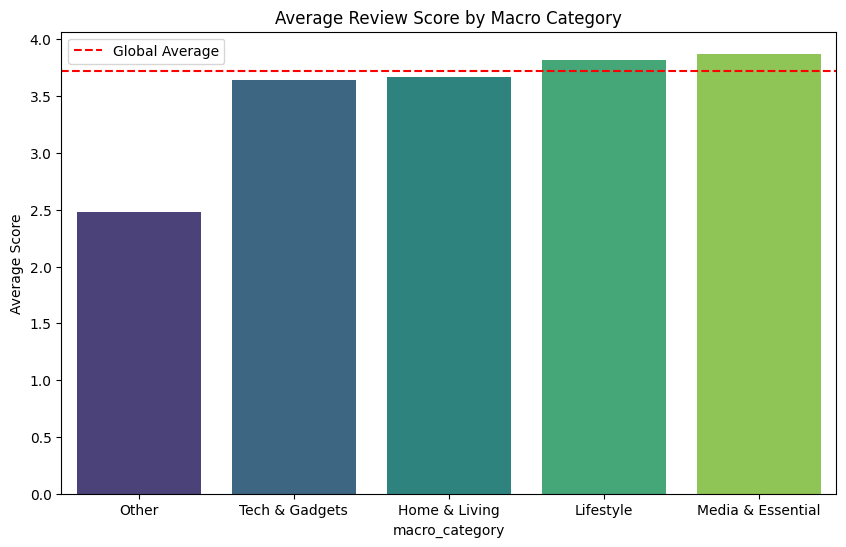

In [11]:
category_stats = train_clean.groupby('macro_category')['review_score'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')
plt.title('Average Review Score by Macro Category')
plt.ylabel('Average Score')
plt.axhline(train_clean['review_score'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

In [12]:
category_counts = train_clean['macro_category'].value_counts()
print(category_counts)

macro_category
Home & Living        11978
Lifestyle            10157
Tech & Gadgets        7049
Media & Essential     2099
Other                   29
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_828\1766647987.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')


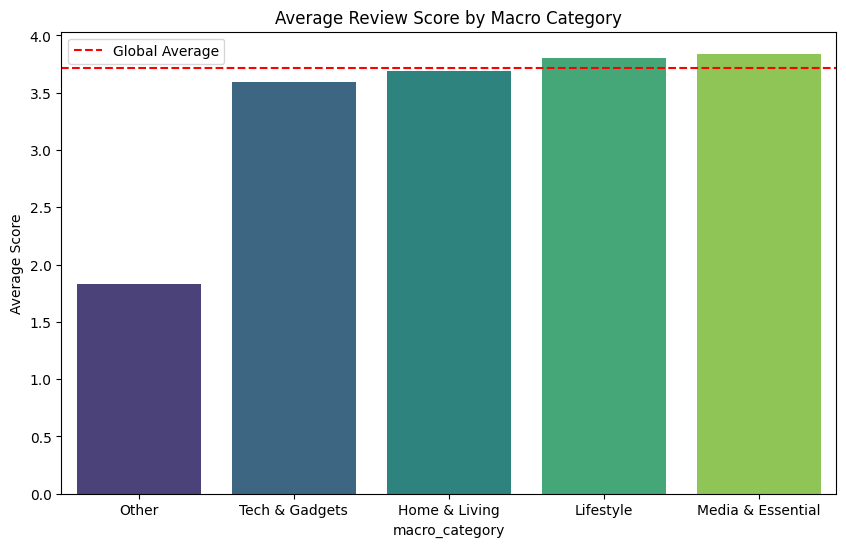

In [13]:
category_stats = test_clean.groupby('macro_category')['review_score'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')
plt.title('Average Review Score by Macro Category')
plt.ylabel('Average Score')
plt.axhline(test_clean['review_score'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

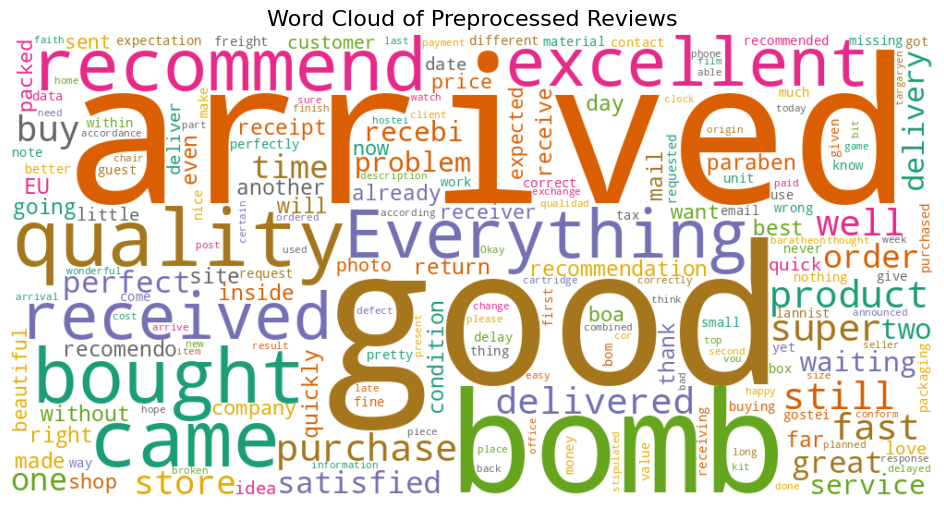

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_cleaned_text = " ".join(text for text in train_clean['english_review_text'].astype(str))


wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    max_words=200,       
    colormap='Dark2',       
    collocations=False     
).generate(all_cleaned_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Preprocessed Reviews', fontsize=16)
plt.show()

In [15]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


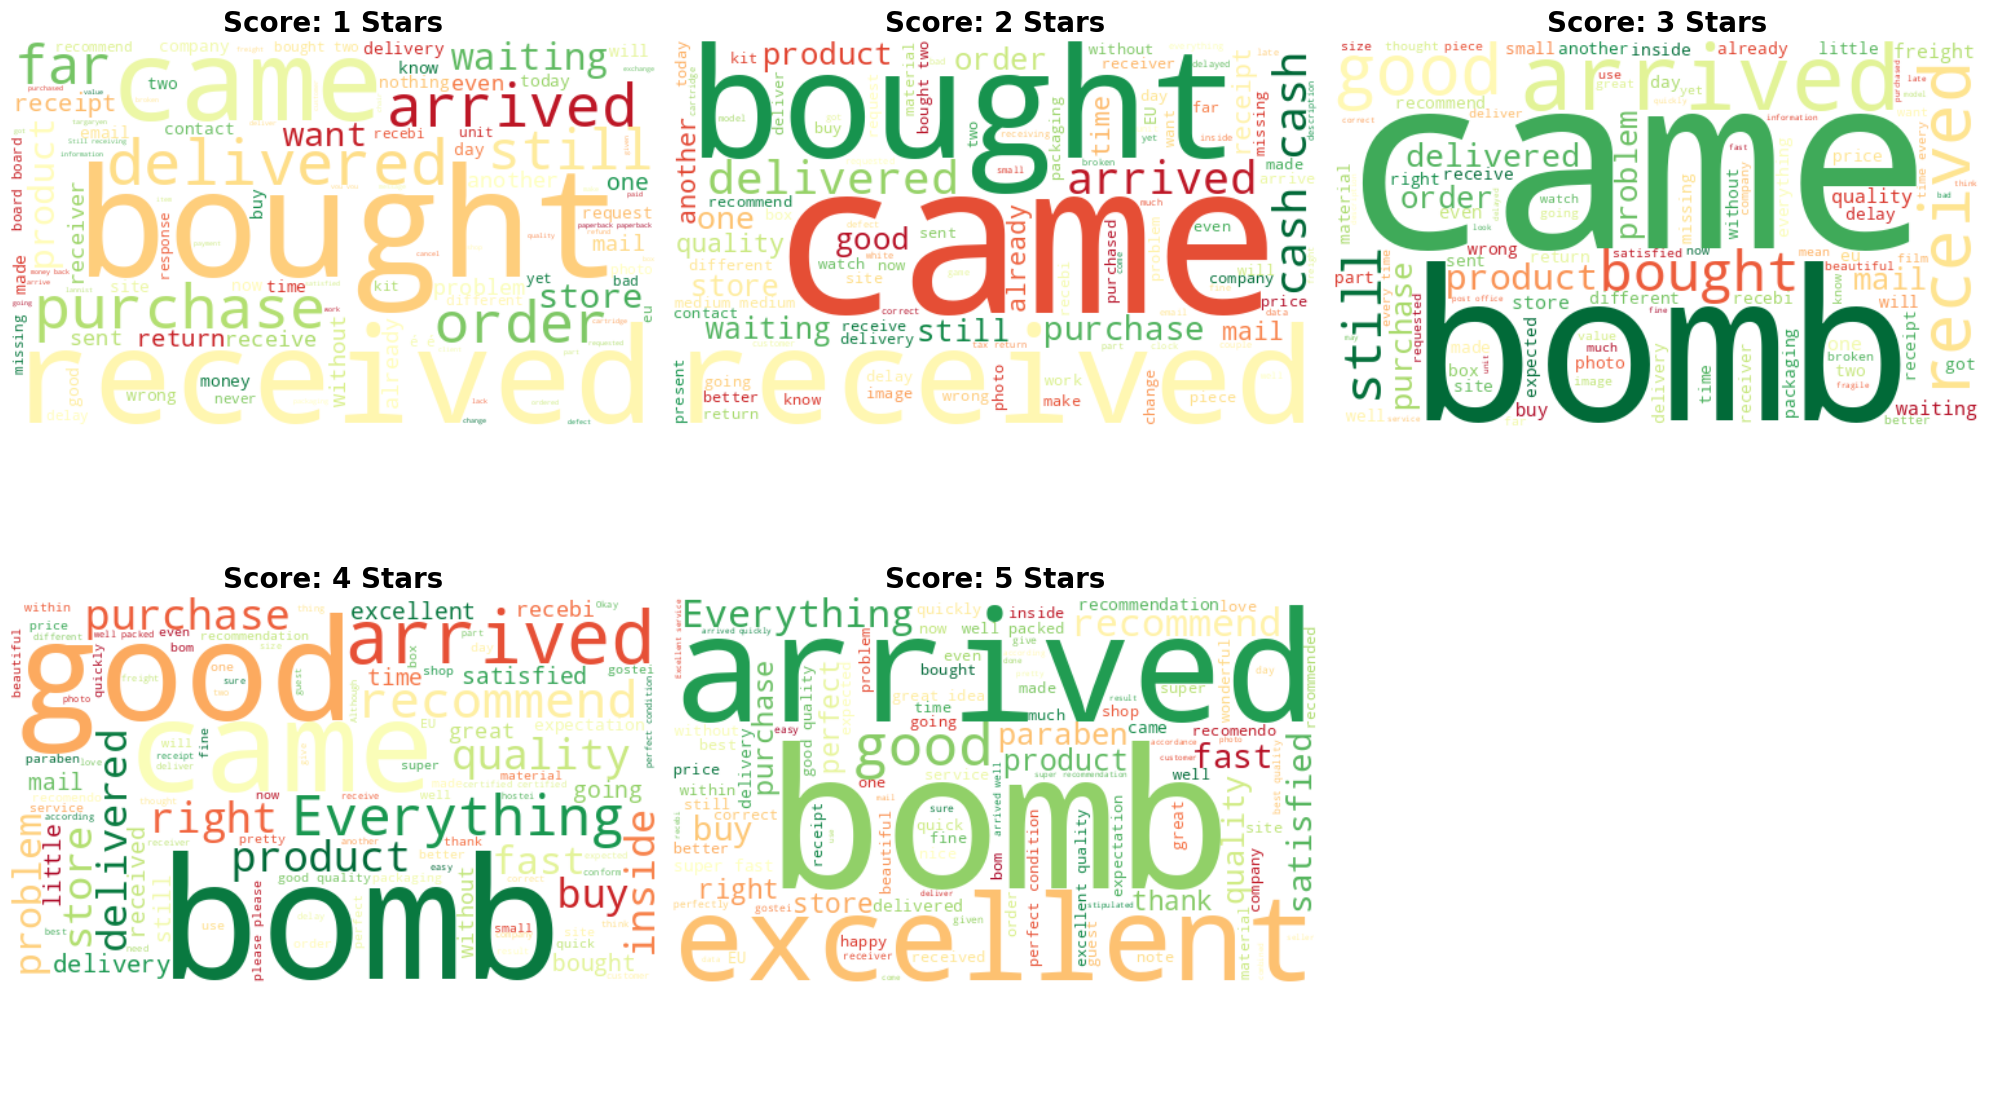

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, score in enumerate([1, 2, 3, 4, 5]):
    subset = train_clean[train_clean['review_score'] == score]
    
    text = " ".join(review for review in subset['english_review_text'].astype(str))
    
    if len(text.strip()) > 0:
        wc = WordCloud(
            width=500, 
            height=300, 
            background_color='white',
            max_words=100,
            colormap='RdYlGn'
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Score: {score} Stars', fontsize=20, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center')
        
    axes[i].axis('off')

axes[5].axis('off')

plt.tight_layout()
plt.show()

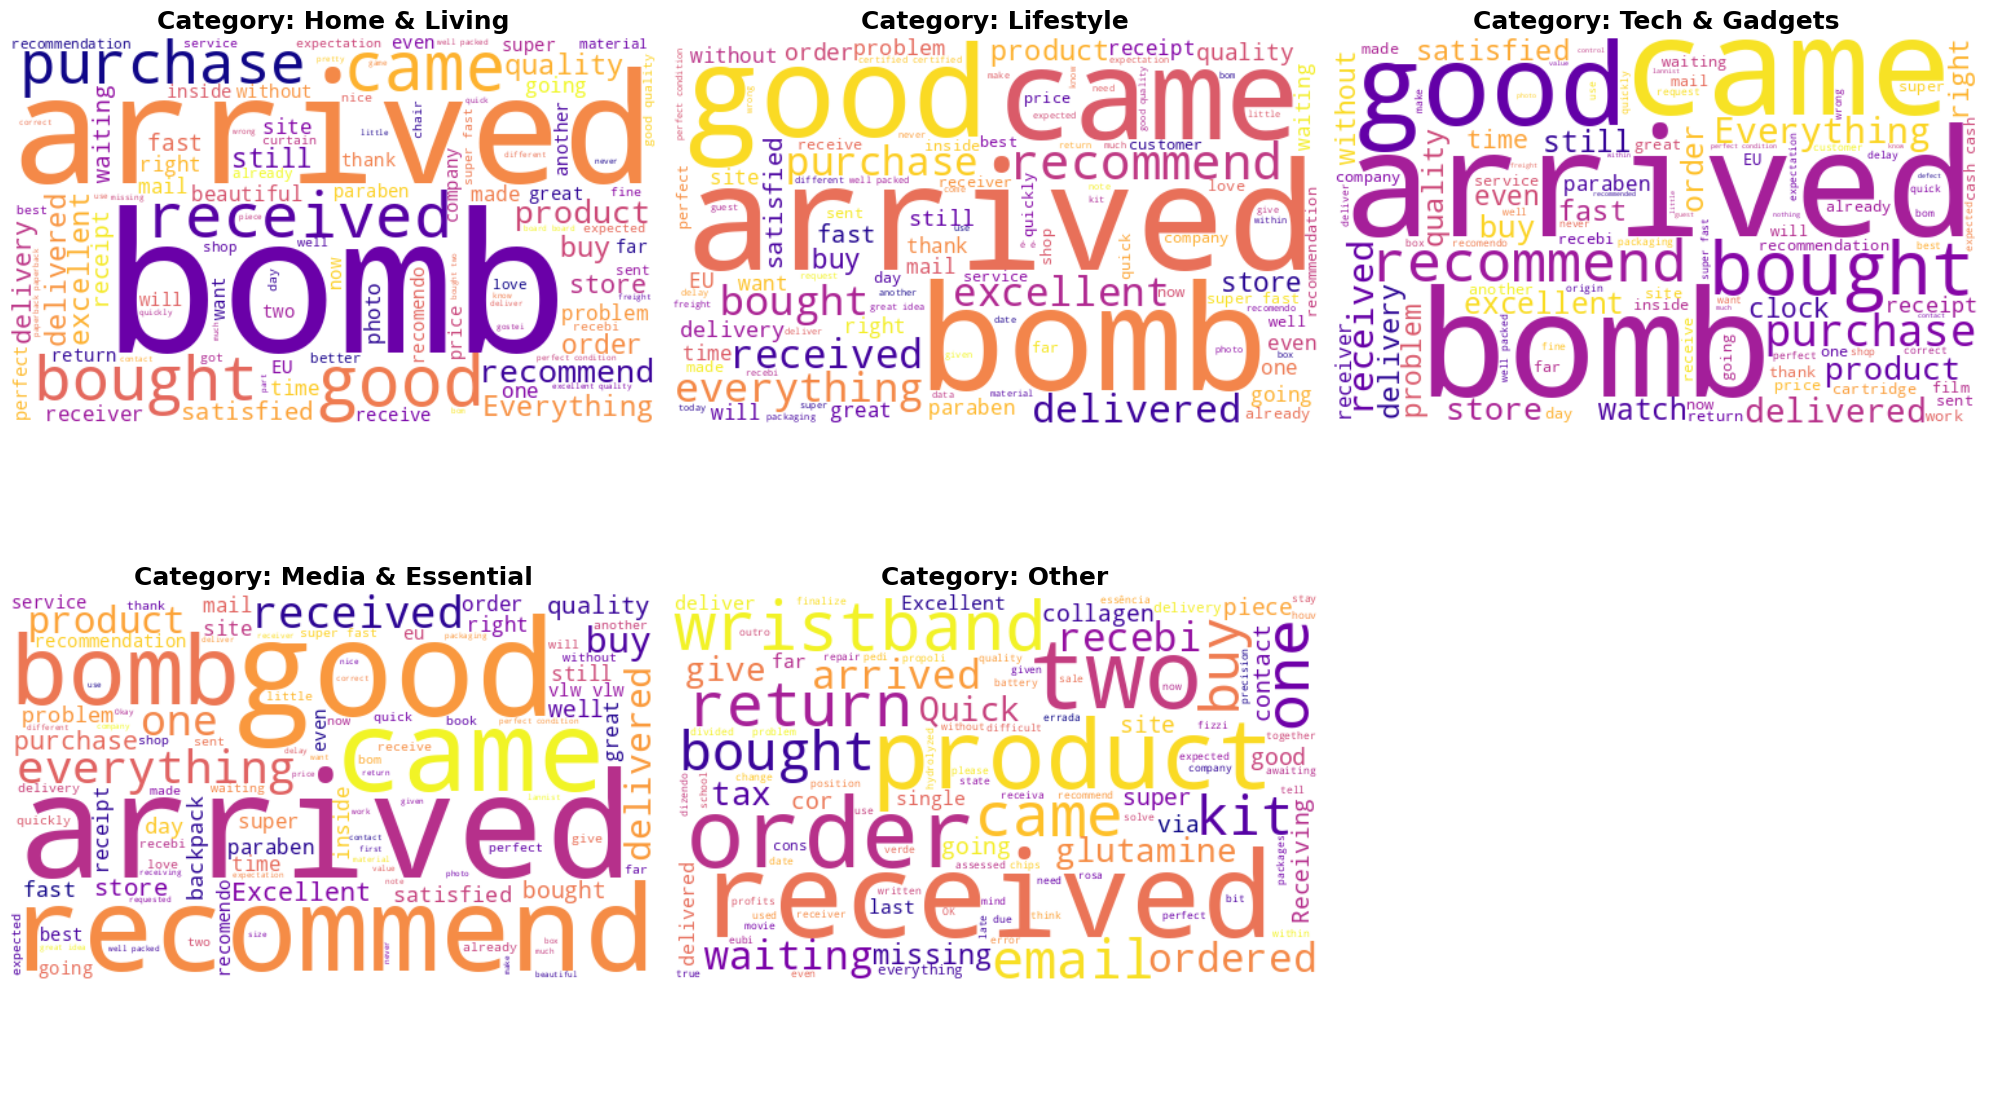

In [21]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math

categories = train_clean['macro_category'].unique()
num_categories = len(categories)

cols = 3
rows = math.ceil(num_categories / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes = axes.flatten()

for i, cat in enumerate(categories):
    subset = train_clean[train_clean['macro_category'] == cat]
    
    text = " ".join(review for review in subset['english_review_text'].astype(str))
    
    if len(text.strip()) > 0:
        wc = WordCloud(
            width=500, 
            height=300, 
            background_color='white',
            max_words=100,
            colormap='plasma' 
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Category: {cat}', fontsize=18, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, f'No Data for {cat}', ha='center')
        
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [20]:
from sentence_transformers import SentenceTransformer, util

model_sim = SentenceTransformer('sentence-transformers/LaBSE')

sample = train_clean.sample(500)
portuguese_texts = sample['review_text'].tolist()
english_texts = sample['english_review_text'].tolist()

embeddings_pt = model_sim.encode(portuguese_texts)
embeddings_en = model_sim.encode(english_texts)

cos_sim = util.cos_sim(embeddings_pt, embeddings_en)
avg_score = cos_sim.diagonal().mean().item()

print(f"平均語義相似度分數: {avg_score:.4f} (越接近 1 越好)")

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

C:\Users\user\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--sentence-transformers--LaBSE. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

平均語義相似度分數: 0.6574 (越接近 1 越好)


In [22]:
df_all = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)
low_score_df = df_all[df_all['review_score'] <= 2]
low_score_docs = low_score_df['english_review_text'].astype(str).tolist()
print(f"合併完成，共有 {len(low_score_docs)} 條負評準備進行主題建模。")

合併完成，共有 9869 條負評準備進行主題建模。


In [51]:
category_counts = df_all['macro_category'].value_counts()
print(category_counts)

macro_category
Home & Living        15006
Lifestyle            12697
Tech & Gadgets        8746
Media & Essential     2656
Other                   35
Name: count, dtype: int64


In [46]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
import torch
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

custom_stopwords = ["the", "to", "and", "is", "it", "of", "for", "was", "my", "bought", "product", "received", "in", "with", "have", "so", "but"]
vectorizer_model = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2))

representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics=10, 
    calculate_probabilities=False, 
    verbose=True
)

topics, _ = topic_model.fit_transform(low_score_docs)

print("\n--- Final Meaningful Topics ---")
print(topic_model.get_topic_info().head(11))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-22 21:43:32,493 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/309 [00:00<?, ?it/s]

2026-04-22 21:43:50,711 - BERTopic - Embedding - Completed ✓
2026-04-22 21:43:50,712 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 21:43:53,256 - BERTopic - Dimensionality - Completed ✓
2026-04-22 21:43:53,257 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 21:43:53,562 - BERTopic - Cluster - Completed ✓
2026-04-22 21:43:53,562 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-22 21:43:53,866 - BERTopic - Representation - Completed ✓
2026-04-22 21:43:53,867 - BERTopic - Topic reduction - Reducing number of topics
2026-04-22 21:43:53,902 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 21:43:54,790 - BERTopic - Representation - Completed ✓
2026-04-22 21:43:54,793 - BERTopic - Topic reduction - Reduced number of topics from 167 to 10



--- Final Meaningful Topics ---
   Topic  Count  \
0     -1   3173   
1      0   5287   
2      1    469   
3      2    459   
4      3    307   
5      4     65   
6      5     60   
7      6     24   
8      7     13   
9      8     12   

                                                                          Name  \
0                                        -1_receipt_delivered_delivery_receive   
1                                  0_delivered_purchase_still receiving_return   
2                                1_recebi recebi_recebi_recebi todo_nao recebi   
3                                     2_faith given_you faith_only faith_faith   
4                          3_still waiting_waiting you_am waiting_been waiting   
5                               4_error_error occurred_error now_error message   
6      5_authorities still_hands authorities_authorities just_authorities when   
7                                 6_are bombs_bombs bombs_bombs are_bomb bombs   
8                  

In [57]:
original_topics_count = len(topic_model.topic_labels_) - 1
print(f"在合併為 10 個之前，模型最初自動發現了 {original_topics_count} 個主題。")

在合併為 10 個之前，模型最初自動發現了 9 個主題。


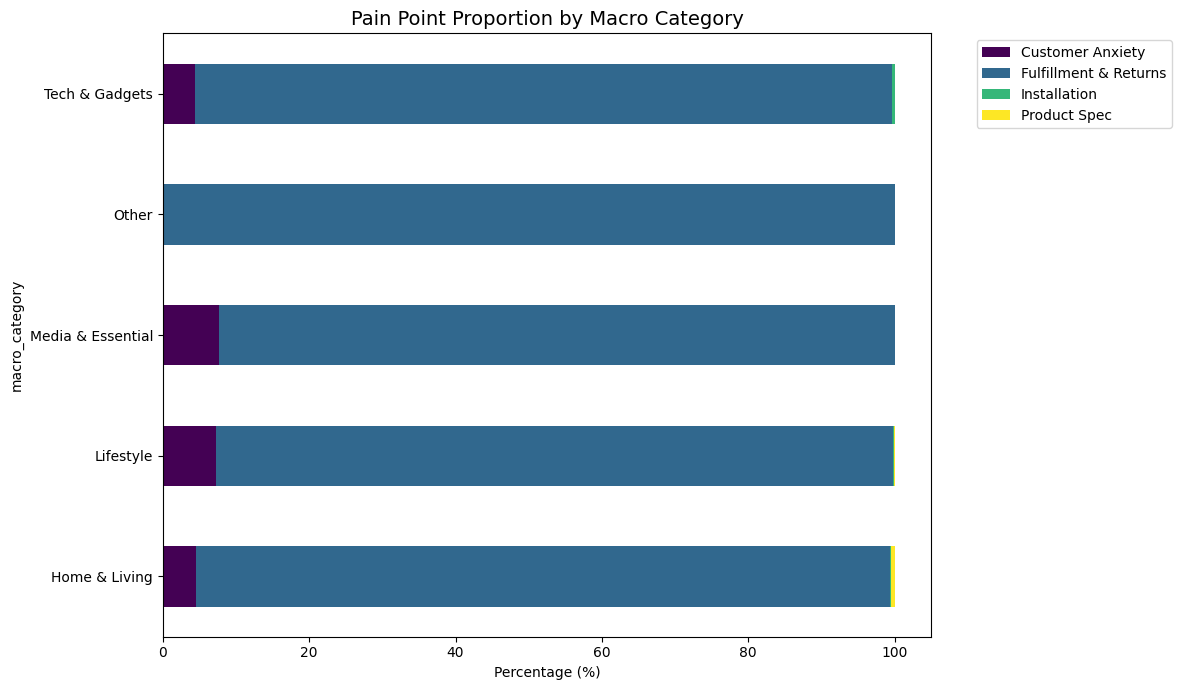

In [53]:
low_score_df['topic_id'] = topics 

target_topics = [0, 3, 7, 8]
important_segment = low_score_df[low_score_df['topic_id'].isin(target_topics)].copy()

topic_mapping = {
    0: "Fulfillment & Returns",
    3: "Customer Anxiety",
    7: "Product Spec",
    8: "Installation"
}
important_segment['Theme'] = important_segment['topic_id'].map(topic_mapping)

category_topic_dist = pd.crosstab(important_segment['macro_category'], important_segment['Theme'])
category_topic_pct = category_topic_dist.div(category_topic_dist.sum(1), axis=0) * 100

import matplotlib.pyplot as plt
category_topic_pct.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Pain Point Proportion by Macro Category', fontsize=14)
plt.xlabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


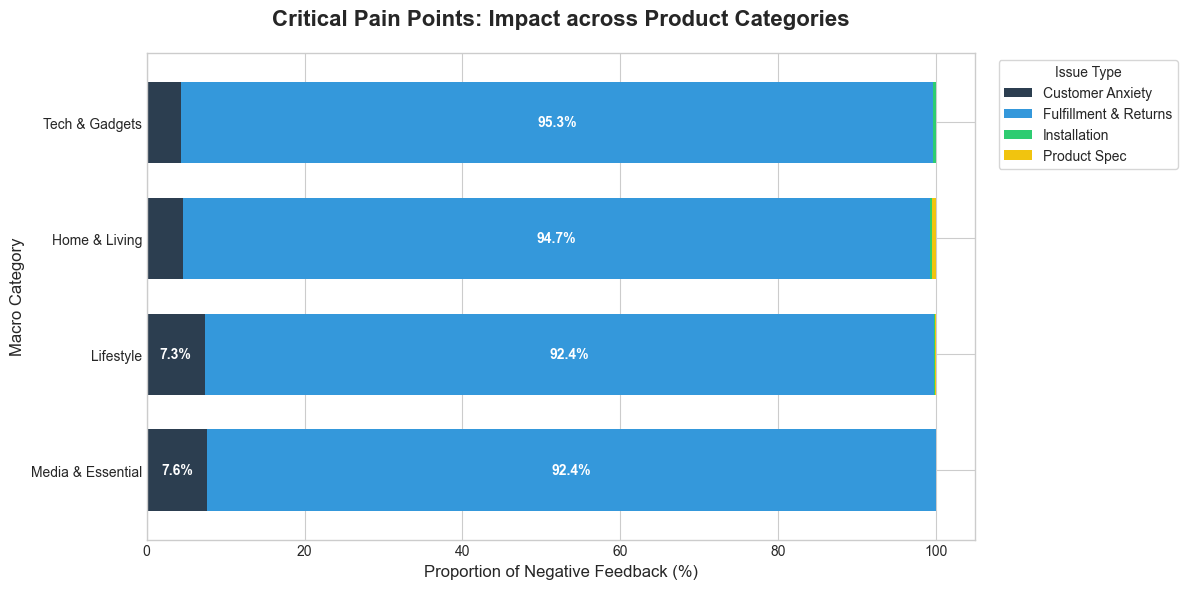

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_pct = category_topic_pct.drop(index='Other', errors='ignore')
filtered_pct = filtered_pct.sort_values(by='Fulfillment & Returns', ascending=True)

plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2c3e50', '#3498db', '#2ecc71', '#f1c40f']
filtered_pct.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.7)

plt.title('Critical Pain Points: Impact across Product Categories', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Proportion of Negative Feedback (%)', fontsize=12)
plt.ylabel('Macro Category', fontsize=12)
plt.legend(title='Issue Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

for p in ax.patches:
    width = p.get_width()
    if width > 5: 
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, 
                f'{width:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


In [55]:
diagnosis_matrix = category_topic_pct.drop(index='Other', errors='ignore').copy()

diagnosis_matrix = diagnosis_matrix[['Fulfillment & Returns', 'Customer Anxiety', 'Product Spec', 'Installation']]

styled_matrix = diagnosis_matrix.style.background_gradient(cmap='Blues', axis=1)\
    .format("{:.2f}%")\
    .set_caption("Negative Review Diagnosis Matrix: Issues by Category")

print("--- Customer Pain Point Diagnosis Matrix ---")
print(diagnosis_matrix.round(2))

styled_matrix


--- Customer Pain Point Diagnosis Matrix ---
Theme              Fulfillment & Returns  Customer Anxiety  Product Spec  \
macro_category                                                             
Home & Living                      94.73              4.59          0.50   
Lifestyle                          92.42              7.33          0.12   
Media & Essential                  92.36              7.64          0.00   
Tech & Gadgets                     95.26              4.34          0.00   

Theme              Installation  
macro_category                   
Home & Living              0.18  
Lifestyle                  0.12  
Media & Essential          0.00  
Tech & Gadgets             0.41  


Theme,Fulfillment & Returns,Customer Anxiety,Product Spec,Installation
macro_category,,,,
Home & Living,94.73%,4.59%,0.50%,0.18%
Lifestyle,92.42%,7.33%,0.12%,0.12%
Media & Essential,92.36%,7.64%,0.00%,0.00%
Tech & Gadgets,95.26%,4.34%,0.00%,0.41%


In [56]:
final_matrix = category_topic_pct.drop(index='Other', errors='ignore')
final_matrix = final_matrix[['Fulfillment & Returns', 'Customer Anxiety', 'Product Spec', 'Installation']]

styled_df = final_matrix.style \
    .background_gradient(cmap='Blues', axis=1) \
    .format("{:.2f}%") \
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px',
        'border': '1px solid #eeeeee',
        'font-family': 'Arial, sans-serif'
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('color', '#2c3e50'), 
            ('font-size', '18px'), 
            ('font-weight', 'bold'),
            ('padding-bottom', '15px'),
            ('text-align', 'left')
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#f8f9fa'),
            ('color', '#34495e'),
            ('font-weight', 'bold'),
            ('border-bottom', '2px solid #dee2e6')
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('background-color', '#ffffff'),
            ('text-align', 'left'),
            ('min-width', '150px')
        ]}
    ]) \
    .set_caption("Customer Pain Point Diagnosis Matrix")

styled_df


Theme,Fulfillment & Returns,Customer Anxiety,Product Spec,Installation
macro_category,,,,
Home & Living,94.73%,4.59%,0.50%,0.18%
Lifestyle,92.42%,7.33%,0.12%,0.12%
Media & Essential,92.36%,7.64%,0.00%,0.00%
Tech & Gadgets,95.26%,4.34%,0.00%,0.41%


In [59]:
total_counts = important_segment['Theme'].value_counts()
total_pct = (total_counts / total_counts.sum() * 100)

total_row = pd.DataFrame([total_pct], index=['Total (Overall)'])
total_row = total_row[['Fulfillment & Returns', 'Customer Anxiety', 'Product Spec', 'Installation']]

matrix_with_total = pd.concat([final_matrix, total_row])

styled_final = matrix_with_total.style \
    .background_gradient(cmap='Blues', axis=1) \
    .format("{:.2f}%") \
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px',
        'border': '1px solid #eeeeee',
        'font-family': 'Arial, sans-serif'
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#34495e')]},
        {'selector': 'tr:last-child', 'props': [('font-weight', 'bold'), ('background-color', '#f1f8ff')]}
    ]) \
    .set_caption("Customer Pain Point Diagnosis Matrix with Overall Total")

styled_final

Theme,Fulfillment & Returns,Customer Anxiety,Product Spec,Installation
Home & Living,94.73%,4.59%,0.50%,0.18%
Lifestyle,92.42%,7.33%,0.12%,0.12%
Media & Essential,92.36%,7.64%,0.00%,0.00%
Tech & Gadgets,95.26%,4.34%,0.00%,0.41%
Total (Overall),94.09%,5.46%,0.23%,0.21%


In [62]:
import dataframe_image as dfi

dfi.export(styled_final, 'customer_pain_point_matrix.png', table_conversion='chrome')

print("✅ Image saved as 'customer_pain_point_matrix.png'")

✅ Image saved as 'customer_pain_point_matrix.png'


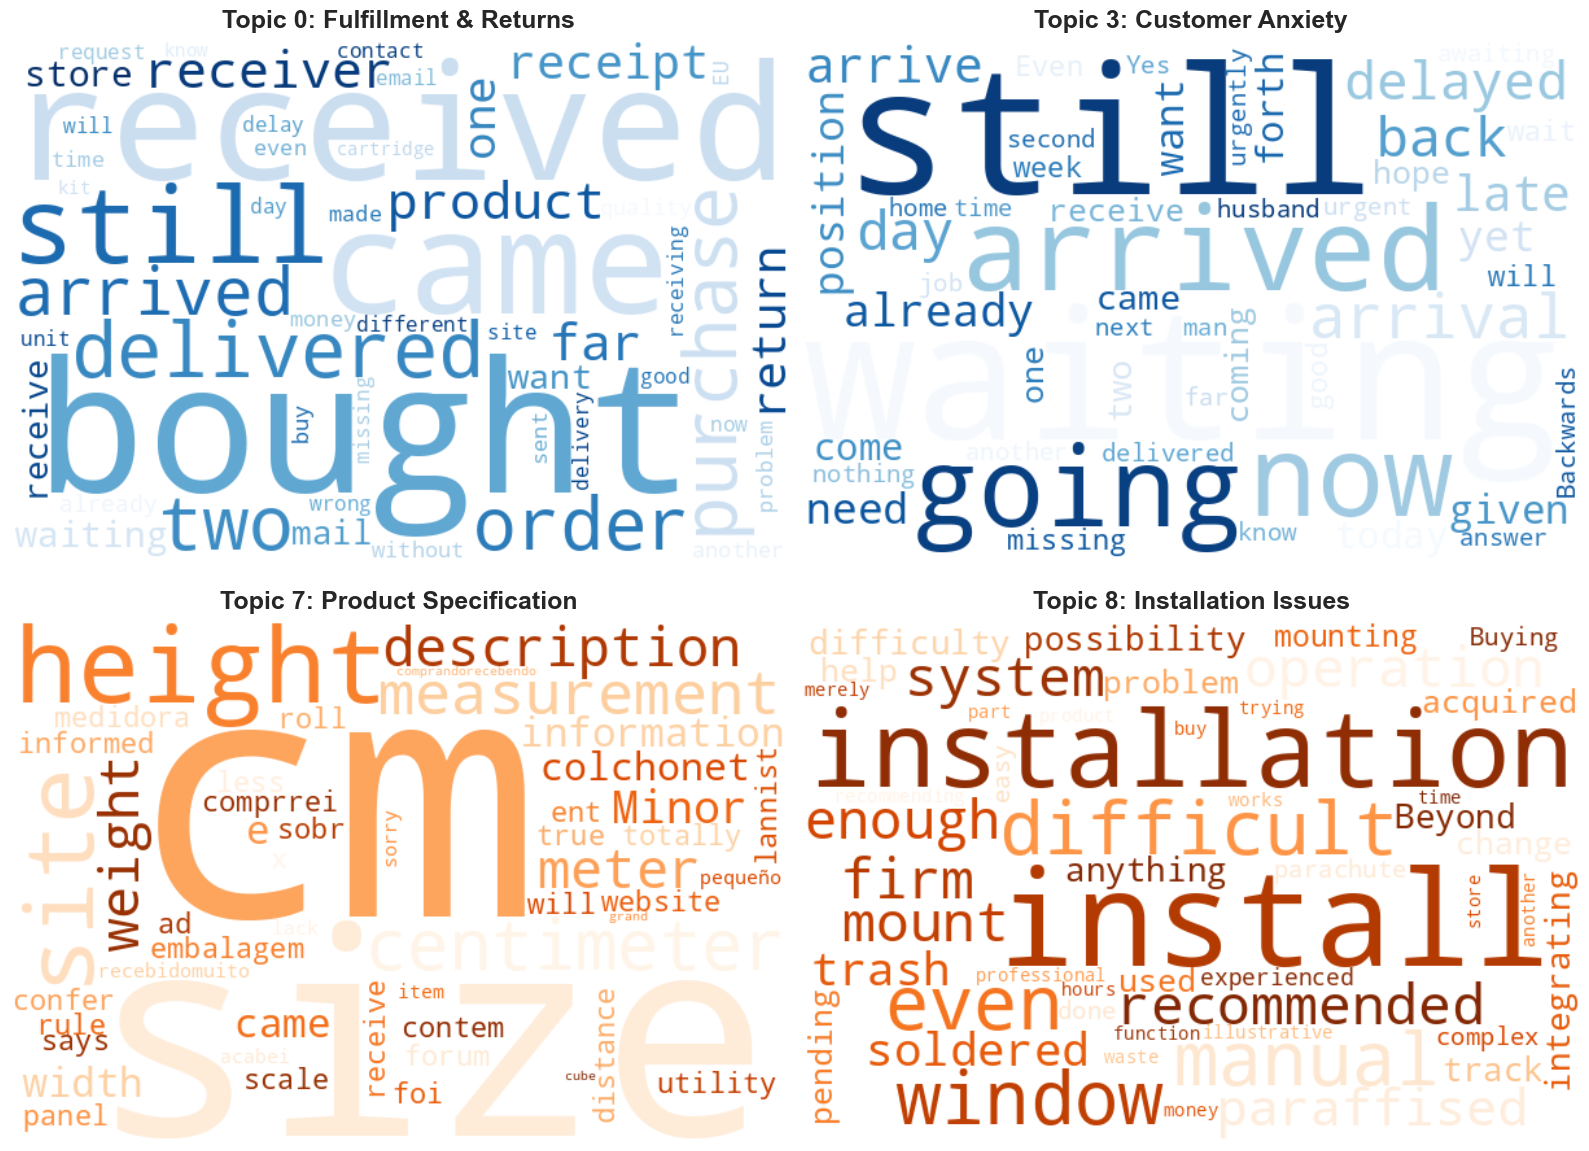

In [58]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

target_topics = [0, 3, 7, 8]
topic_titles = {
    0: "Fulfillment & Returns",
    3: "Customer Anxiety",
    7: "Product Specification",
    8: "Installation Issues"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, t_id in enumerate(target_topics):
    subset_docs = [doc for j, doc in enumerate(low_score_docs) if topics[j] == t_id]
    text = " ".join(subset_docs)
    
    if len(text.strip()) > 0:
        color_map = 'Blues' if t_id in [0, 3] else 'Oranges'
        
        wc = WordCloud(
            width=600, height=400, 
            background_color='white',
            colormap=color_map,
            max_words=50,
            collocations=False
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"Topic {t_id}: {topic_titles[t_id]}", fontsize=18, fontweight='bold', pad=10)
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center')
        
    axes[i].axis('off')

plt.tight_layout()
plt.show()
